# N02B — Locked OAI-to-NHANES Transfer Evaluation

**Research question.** How much performance does the frozen OAI-trained concept bottleneck lose on NHANES III?

This notebook loads only the final N02A checkpoints. It performs no image-model training and no checkpoint selection. It evaluates the same three-seed ensemble on OAI test and NHANES confirmation.


## Reader Guide

**Pipeline role:** Performs locked OAI-to-NHANES transfer evaluation using the N02A ensemble exactly as frozen.

**Boundary:** this stage performs no image-model training, checkpoint selection, or checkpoint modification. **Produces:** OAI test and NHANES confirmation predictions, transfer metrics, uncertainty estimates, and an audit certificate.

**Reading route:** verify the input gate -> load the ensemble -> run locked inference -> quantify generalization loss -> inspect uncertainty and final figures.

## Evaluation contract

- Checkpoints come only from `MasterThesis/Final Pipeline/checkpoints/N02A`.
- OAI predictions and temperatures come only from the final N02A folders.
- NHANES is used only for locked external evaluation.
- No checkpoint, temperature, architecture or ensemble member changes after NHANES access.
- All outputs are saved under the N02B folders.


In [ ]:



from concurrent.futures import ThreadPoolExecutor, as_completed

from dataclasses import dataclass

from datetime import datetime, timezone

from pathlib import Path

from time import perf_counter

from typing import Any

import hashlib

import importlib

import json

import os

import shutil

import subprocess

import sys

import uuid

import warnings



IN_COLAB = "google.colab" in sys.modules



if IN_COLAB:

    from google.colab import drive

    drive.mount(

        "/content/drive",

        force_remount=False,

    )





def ensure_package(

    package: str,

    import_name: str | None = None,

) -> None:

    module = import_name or package



    try:

        importlib.import_module(module)

    except ImportError:

        subprocess.check_call([

            sys.executable,

            "-m",

            "pip",

            "install",

            "-q",

            package,

        ])





ensure_package("timm")



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from PIL import Image, ImageOps

from sklearn.metrics import (

    accuracy_score,

    balanced_accuracy_score,

    cohen_kappa_score,

    confusion_matrix,

    f1_score,

    log_loss,

    mean_absolute_error,

    mean_squared_error,

    precision_recall_fscore_support,

)

import timm

import torch

from torch import nn

import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset

from torchvision import transforms

from tqdm.auto import tqdm





@dataclass(frozen=True)

class EvaluationConfig:

    backbone: str = "convnext_tiny.fb_in1k"

    image_size: int = 320

    batch_size_a100: int = 48

    batch_size_other_gpu: int = 24

    num_workers: int = 4

    copy_workers: int = 8

    ece_bins: int = 15

    bootstrap_repetitions: int = 2000

    bootstrap_seed: int = 20260805





CONFIG = EvaluationConfig()



FINAL_ROOT = Path(

    "/content/drive/MyDrive/MasterThesis/Final Pipeline"

)



DATA_DIR = FINAL_ROOT / "data" / "N01"

N02A_CHECKPOINTS = FINAL_ROOT / "checkpoints" / "N02A"

N02A_TABLES = FINAL_ROOT / "tables" / "N02A"

N02A_PREDICTIONS = FINAL_ROOT / "predictions" / "N02A"

N02A_MANIFESTS = FINAL_ROOT / "manifests" / "N02A"



RESULT_DIR = FINAL_ROOT / "results" / "N02B"

TABLE_DIR = FINAL_ROOT / "tables" / "N02B"

FIGURE_DIR = FINAL_ROOT / "figures" / "N02B"

PREDICTION_DIR = FINAL_ROOT / "predictions" / "N02B"

MANIFEST_DIR = FINAL_ROOT / "manifests" / "N02B"



NHANES_IMAGE_SOURCE = Path(

    "/content/drive/MyDrive/Master Thesis/nhanes3/processed"

)



LOCAL_IMAGE_DIR = Path(

    "/content/n02b_nhanes_images"

)



for folder in (

    RESULT_DIR,

    TABLE_DIR,

    FIGURE_DIR,

    PREDICTION_DIR,

    MANIFEST_DIR,

):

    folder.mkdir(

        parents=True,

        exist_ok=True,

    )



    for path in folder.iterdir():

        if path.is_file():

            path.unlink()



PROTOCOL = "N02B_LOCKED_TRANSFER"

NOTEBOOK_NAME = "N02B_Locked_Transfer_Evaluation.ipynb"



RUN_STARTED_UTC = datetime.now(

    timezone.utc

)



RUN_STARTED_TIMESTAMP = (

    RUN_STARTED_UTC.timestamp()

)



DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)



if DEVICE.type != "cuda":

    raise RuntimeError(

        "N02B requires a GPU runtime."

    )



GPU_NAME = torch.cuda.get_device_name(0)



BATCH_SIZE = (

    CONFIG.batch_size_a100

    if "A100" in GPU_NAME.upper()

    else CONFIG.batch_size_other_gpu

)



AMP_ENABLED = True

PIN_MEMORY = True



torch.backends.cudnn.benchmark = True

torch.set_float32_matmul_precision("high")



print("GPU:", GPU_NAME)

print("Batch size:", BATCH_SIZE)

print("DataLoader workers:", CONFIG.num_workers)

print("Image-model training: NO")


Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB
Batch size: 48
DataLoader workers: 4
Image-model training: NO


In [ ]:



def sha256_file(

    path: Path,

    chunk_size: int = 1024 * 1024,

) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(

            lambda: handle.read(chunk_size),

            b"",

        ):

            digest.update(block)

    return digest.hexdigest()





def atomic_csv(

    frame: pd.DataFrame,

    path: Path,

) -> None:

    path.parent.mkdir(

        parents=True,

        exist_ok=True,

    )

    temporary = path.with_suffix(

        path.suffix + ".tmp"

    )

    frame.to_csv(

        temporary,

        index=False,

    )

    temporary.replace(path)





def atomic_json(

    payload: dict[str, Any],

    path: Path,

) -> None:

    path.parent.mkdir(

        parents=True,

        exist_ok=True,

    )

    temporary = path.with_suffix(

        path.suffix + ".tmp"

    )

    temporary.write_text(

        json.dumps(

            payload,

            indent=2,

        ),

        encoding="utf-8",

    )

    temporary.replace(path)





def robust_torch_load(

    source: Path,

) -> dict[str, Any]:

    if (

        not source.exists()

        or source.stat().st_size == 0

    ):

        raise FileNotFoundError(

            f"Checkpoint is missing or empty: {source}"

        )



    staging = Path(

        "/content/n02b_checkpoint_staging"

    )

    staging.mkdir(

        parents=True,

        exist_ok=True,

    )

    local_path = (

        staging

        / f"{source.name}.{uuid.uuid4().hex}.read"

    )



    try:

        shutil.copyfile(

            source,

            local_path,

        )

        return torch.load(

            local_path,

            map_location=DEVICE,

            weights_only=False,

        )

    finally:

        local_path.unlink(

            missing_ok=True

        )





def locate_required_file(

    candidates: list[Path],

    label: str,

) -> Path:

    existing = [

        path

        for path in candidates

        if path.exists()

        and path.stat().st_size > 0

    ]

    if len(existing) != 1:

        raise FileNotFoundError(

            f"Expected exactly one {label}. "

            f"Found: {[str(path) for path in existing]}"

        )

    return existing[0]


## Input gate

All result artifacts must already be inside `MasterThesis/Final Pipeline`.
The only path outside that tree is the raw NHANES image directory.


In [ ]:



OAI_COHORT_PATH = DATA_DIR / "oai_cohort.csv"

NHANES_COHORT_PATH = DATA_DIR / "nhanes_cohort.csv"



OAI_PREDICTION_PATH = (

    N02A_PREDICTIONS

    / "oai_predictions.csv"

)



TEMPERATURE_PATH = (

    N02A_TABLES

    / "T04_temperatures.csv"

)



CHECKPOINT_MANIFEST_PATH = (

    N02A_MANIFESTS

    / "checkpoint_manifest.csv"

)



required_inputs = [

    OAI_COHORT_PATH,

    NHANES_COHORT_PATH,

    OAI_PREDICTION_PATH,

    TEMPERATURE_PATH,

    CHECKPOINT_MANIFEST_PATH,

]



missing_inputs = [

    path

    for path in required_inputs

    if (

        not path.exists()

        or path.stat().st_size == 0

    )

]



if missing_inputs:

    raise FileNotFoundError(

        "Missing final-pipeline inputs:\n"

        + "\n".join(

            f" - {path}"

            for path in missing_inputs

        )

    )



if not NHANES_IMAGE_SOURCE.exists():

    raise FileNotFoundError(

        f"Missing NHANES images: {NHANES_IMAGE_SOURCE}"

    )



OAI = pd.read_csv(

    OAI_COHORT_PATH,

    low_memory=False,

)



NHANES = pd.read_csv(

    NHANES_COHORT_PATH,

    low_memory=False,

)



OAI_PREDICTIONS = pd.read_csv(

    OAI_PREDICTION_PATH,

    low_memory=False,

)



TEMPERATURES = pd.read_csv(

    TEMPERATURE_PATH,

    low_memory=False,

)



CHECKPOINT_MANIFEST = pd.read_csv(

    CHECKPOINT_MANIFEST_PATH,

    low_memory=False,

)



required_oai = {

    "knee_key",

    "patient_id",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

}



required_nhanes = {

    "filename",

    "knee_key",

    "patient_id",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

    "analysis_subset",

}



missing_oai = required_oai - set(OAI.columns)

missing_nhanes = required_nhanes - set(NHANES.columns)



if missing_oai:

    raise KeyError(

        f"OAI cohort is missing: {sorted(missing_oai)}"

    )



if missing_nhanes:

    raise KeyError(

        f"NHANES cohort is missing: {sorted(missing_nhanes)}"

    )



if not OAI["knee_key"].is_unique:

    raise RuntimeError(

        "OAI knee_key is not unique."

    )



if not NHANES["knee_key"].is_unique:

    raise RuntimeError(

        "NHANES knee_key is not unique."

    )



if "model_split" not in OAI_PREDICTIONS.columns:

    raise KeyError(

        "N02A OAI predictions do not contain model_split."

    )



if not OAI_PREDICTIONS["knee_key"].is_unique:

    raise RuntimeError(

        "N02A OAI prediction knee_key is not unique."

    )



if set(

    OAI_PREDICTIONS["knee_key"].astype(str)

) != set(

    OAI["knee_key"].astype(str)

):

    raise RuntimeError(

        "N02A predictions do not match the frozen OAI cohort."

    )



NHANES = (

    NHANES.loc[

        NHANES[

            "analysis_subset"

        ].astype(str).str.lower().eq(

            "confirmation"

        )

    ]

    .copy()

    .reset_index(drop=True)

)



if len(NHANES) == 0:

    raise RuntimeError(

        "NHANES confirmation subset is empty."

    )



if len(CHECKPOINT_MANIFEST) != 3:

    raise RuntimeError(

        "Exactly three checkpoints are required."

    )



if (

    CHECKPOINT_MANIFEST["seed"]

    .astype(int)

    .nunique()

    != 3

):

    raise RuntimeError(

        "Checkpoint seeds are not unique."

    )



print("OAI knees:", len(OAI))

print("NHANES confirmation knees:", len(NHANES))

print("Checkpoints:", len(CHECKPOINT_MANIFEST))

print("Input gate: PASS")


OAI knees: 5252
NHANES confirmation knees: 2392
Checkpoints: 3
Input gate: PASS


In [ ]:



IMAGENET_MEAN = (

    0.485,

    0.456,

    0.406,

)



IMAGENET_STD = (

    0.229,

    0.224,

    0.225,

)



evaluation_transform = transforms.Compose([

    transforms.Grayscale(

        num_output_channels=3

    ),

    transforms.Resize(

        (

            CONFIG.image_size,

            CONFIG.image_size,

        ),

        interpolation=(

            transforms.InterpolationMode.BILINEAR

        ),

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        IMAGENET_MEAN,

        IMAGENET_STD,

    ),

])





class KneeDataset(Dataset):

    def __init__(

        self,

        frame: pd.DataFrame,

    ):

        self.frame = (

            frame

            .reset_index(drop=True)

            .copy()

        )



    def __len__(self) -> int:

        return len(self.frame)



    def __getitem__(

        self,

        index: int,

    ) -> dict[str, Any]:

        row = self.frame.iloc[index]



        image_path = (

            LOCAL_IMAGE_DIR

            / str(row["filename"])

        )



        with Image.open(image_path) as image:

            image = (

                ImageOps

                .exif_transpose(image)

                .convert("L")

            )



            tensor = evaluation_transform(

                image

            )



        return {

            "image": tensor,

            "row_index": int(index),

        }





print("Evaluation dataset: PASS")


Evaluation dataset: PASS


In [ ]:



def resolve_timm_backbone(requested: str) -> str:

    """

    Keep the exact architecture identifier stored by N02A.



    N02B keeps the exact backbone identifier stored by N02A and loads only

    the frozen checkpoint weights.

    """

    if requested != CONFIG.backbone:

        raise RuntimeError(

            f"N02B permits only {CONFIG.backbone}; received {requested}."

        )



    return requested



class ConceptBottleneckNet(nn.Module):

    def __init__(self, backbone_name: str):

        super().__init__()



        self.requested_backbone = backbone_name

        self.resolved_backbone = resolve_timm_backbone(

            backbone_name

        )



        drop_path_rate = 0.10

        head_dropout = 0.20



        self.encoder = timm.create_model(

            self.resolved_backbone,

            pretrained=False,

            num_classes=0,

            global_pool="avg",

            in_chans=3,

            drop_path_rate=drop_path_rate,

        )



        feature_dimension = self.encoder.num_features



        self.feature_dropout = nn.Dropout(

            head_dropout

        )



        self.concept_heads = nn.ModuleDict({

            "osteophyte_max": nn.Linear(

                feature_dimension,

                4,

            ),

            "sclerosis_max": nn.Linear(

                feature_dimension,

                4,

            ),

            "jsn_max": nn.Linear(

                feature_dimension,

                4,

            ),

        })



        self.concept_mapping = nn.Sequential(

            nn.Linear(12, 64),

            nn.LayerNorm(64),

            nn.GELU(),

            nn.Dropout(head_dropout),

            nn.Linear(64, 5),

        )



        self.direct_kl_head = nn.Linear(

            feature_dimension,

            5,

        )



    def encode(

        self,

        images: torch.Tensor,

    ) -> torch.Tensor:

        return self.feature_dropout(

            self.encoder(images)

        )



    def map_concept_probabilities(

        self,

        probabilities: torch.Tensor,

    ) -> torch.Tensor:

        return self.concept_mapping(

            probabilities

        )



    def forward(

        self,

        images: torch.Tensor,

    ) -> dict[str, Any]:

        features = self.encode(images)



        concept_logits = {

            name: head(features)

            for name, head in self.concept_heads.items()

        }



        predicted_concept_probabilities = torch.cat([

            torch.softmax(

                concept_logits[name],

                dim=1,

            )

            for name in TARGET_COLUMNS

        ], dim=1)



        return {

            "concept_logits": concept_logits,

            "predicted_concept_probabilities": (

                predicted_concept_probabilities

            ),

            "mapped_kl_logits": self.map_concept_probabilities(

                predicted_concept_probabilities

            ),

            "direct_kl_logits": self.direct_kl_head(

                features

            ),

        }


In [ ]:



EVALUATION_ONLY = True



print("Evaluation-only mode: PASS")

print("Image-model training enabled: NO")


Evaluation-only mode: PASS
Image-model training enabled: NO


## Load the frozen ensemble

Checkpoint hashes are checked against the final N02A manifest. The checkpoint-internal legacy protocol string is not used as a pipeline dependency.


In [ ]:



PRIMARY_BACKBONE = CONFIG.backbone

TARGET_COLUMNS = (

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

)



expected_seeds = sorted(

    CHECKPOINT_MANIFEST[

        "seed"

    ].astype(int).tolist()

)



if len(set(expected_seeds)) != 3:

    raise RuntimeError(

        "Checkpoint seeds must be unique."

    )



required_temperature_heads = {

    "mapped_kl",

    "direct_kl",

    "oracle_kl",

    *TARGET_COLUMNS,

}



SELECTED_MODELS = []



for row in (

    CHECKPOINT_MANIFEST

    .sort_values("seed")

    .itertuples(index=False)

):

    checkpoint_path = Path(

        row.checkpoint_path

    )



    expected_clean_path = (

        N02A_CHECKPOINTS

        / f"convnext_tiny_seed{int(row.seed)}.pt"

    )



    if checkpoint_path != expected_clean_path:

        raise RuntimeError(

            "Checkpoint manifest contains an unexpected path:\n"

            f"{checkpoint_path}\nExpected:\n{expected_clean_path}"

        )



    observed_hash = sha256_file(

        checkpoint_path

    )



    if observed_hash != str(row.sha256):

        raise RuntimeError(

            f"Checkpoint hash mismatch for seed {int(row.seed)}."

        )



    checkpoint = robust_torch_load(

        checkpoint_path

    )



    checkpoint_seed = int(

        checkpoint.get(

            "seed",

            -1,

        )

    )



    if checkpoint_seed != int(row.seed):

        raise RuntimeError(

            f"Checkpoint seed mismatch for {checkpoint_path}."

        )



    checkpoint_backbone = checkpoint.get(

        "requested_backbone",

        checkpoint.get(

            "backbone",

            None,

        ),

    )



    if checkpoint_backbone != PRIMARY_BACKBONE:

        raise RuntimeError(

            "Checkpoint backbone mismatch. "

            f"Observed: {checkpoint_backbone}"

        )



    seed_temperatures = TEMPERATURES.loc[

        TEMPERATURES["seed"]

        .astype(int)

        .eq(int(row.seed))

    ].copy()



    observed_heads = set(

        seed_temperatures[

            "head"

        ].astype(str)

    )



    if observed_heads != required_temperature_heads:

        raise RuntimeError(

            f"Temperature heads mismatch for seed {int(row.seed)}. "

            f"Observed: {sorted(observed_heads)}"

        )



    temperature_map = {

        str(temp_row.head):

            float(temp_row.temperature)

        for temp_row in (

            seed_temperatures

            .itertuples(index=False)

        )

    }



    if not all(

        np.isfinite(value)

        and value > 0

        for value in temperature_map.values()

    ):

        raise RuntimeError(

            f"Invalid temperature for seed {int(row.seed)}."

        )



    model = ConceptBottleneckNet(

        PRIMARY_BACKBONE

    )



    model.load_state_dict(

        checkpoint[

            "model_state_dict"

        ],

        strict=True,

    )



    model.eval()

    model.to(DEVICE)

    model.to(

        memory_format=torch.channels_last

    )



    for parameter in model.parameters():

        parameter.requires_grad_(False)



    checkpoint_epoch = int(

        checkpoint.get(

            "epoch",

            -1,

        )

    )



    SELECTED_MODELS.append({

        "seed": int(row.seed),

        "model": model,

        "checkpoint_path": str(

            checkpoint_path

        ),

        "checkpoint_sha256": observed_hash,

        "checkpoint_epoch": checkpoint_epoch,

        "temperatures": temperature_map,

    })



    del checkpoint



print("Frozen models loaded:", len(SELECTED_MODELS))

print("Seeds:", [record["seed"] for record in SELECTED_MODELS])

print("Image-model training executed: NO")


Frozen models loaded: 3
Seeds: [367761876, 1023912954, 1767922150]
Image-model training executed: NO


In [ ]:



def entropy(

    probabilities: np.ndarray,

) -> np.ndarray:

    values = np.clip(

        probabilities,

        1e-12,

        1.0,

    )



    return -np.sum(

        values * np.log(values),

        axis=1,

    )





def normalize_rows(

    probabilities: np.ndarray,

) -> np.ndarray:

    values = np.asarray(

        probabilities,

        dtype=np.float64,

    )



    if values.ndim != 2:

        raise ValueError(

            "Probabilities must be two-dimensional."

        )



    if not np.isfinite(values).all():

        raise ValueError(

            "Probabilities contain non-finite values."

        )



    if values.min() < -1e-8:

        raise ValueError(

            "Probabilities contain negative values."

        )



    values = np.clip(

        values,

        0.0,

        None,

    )



    row_sums = values.sum(

        axis=1,

        keepdims=True,

    )



    if (row_sums <= 0).any():

        raise ValueError(

            "A probability row has zero mass."

        )



    return values / row_sums





def apply_temperature(

    probabilities: np.ndarray,

    temperature: float,

) -> np.ndarray:

    value = float(temperature)



    if (

        not np.isfinite(value)

        or value <= 0

    ):

        raise ValueError(

            "Temperature must be positive and finite."

        )



    probabilities = normalize_rows(

        probabilities

    )



    logits = np.log(

        np.clip(

            probabilities,

            1e-7,

            1.0,

        )

    )



    logits = logits / value

    logits = logits - logits.max(

        axis=1,

        keepdims=True,

    )



    return normalize_rows(

        np.exp(logits)

    )





def build_loader(

    frame: pd.DataFrame,

) -> DataLoader:

    arguments = {

        "dataset": KneeDataset(frame),

        "batch_size": BATCH_SIZE,

        "shuffle": False,

        "num_workers": CONFIG.num_workers,

        "pin_memory": PIN_MEMORY,

        "persistent_workers": (

            CONFIG.num_workers > 0

        ),

    }



    if CONFIG.num_workers > 0:

        arguments["prefetch_factor"] = 2



    return DataLoader(

        **arguments

    )





def infer_ensemble(

    frame: pd.DataFrame,

) -> tuple[

    pd.DataFrame,

    dict[str, np.ndarray],

    dict[str, Any],

]:

    working = (

        frame

        .reset_index(drop=True)

        .copy()

    )



    loader = build_loader(

        working

    )



    stores = {

        item["seed"]: {

            "mapped_kl": [],

            "direct_kl": [],

            "osteophyte_max": [],

            "sclerosis_max": [],

            "jsn_max": [],

        }

        for item in SELECTED_MODELS

    }



    observed_indices = []

    start = perf_counter()



    with torch.inference_mode():

        for batch in tqdm(

            loader,

            desc="NHANES inference",

            unit="batch",

        ):

            images = batch[

                "image"

            ].to(

                DEVICE,

                non_blocking=True,

                memory_format=torch.channels_last,

            )



            observed_indices.extend(

                batch[

                    "row_index"

                ].cpu().tolist()

            )



            for item in SELECTED_MODELS:

                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16,

                    enabled=AMP_ENABLED,

                ):

                    output = item["model"](

                        images

                    )



                raw = {

                    "mapped_kl":

                        torch.softmax(

                            output[

                                "mapped_kl_logits"

                            ],

                            dim=1,

                        )

                        .float()

                        .cpu()

                        .numpy(),



                    "direct_kl":

                        torch.softmax(

                            output[

                                "direct_kl_logits"

                            ],

                            dim=1,

                        )

                        .float()

                        .cpu()

                        .numpy(),

                }



                for concept in TARGET_COLUMNS:

                    raw[concept] = (

                        torch.softmax(

                            output[

                                "concept_logits"

                            ][concept],

                            dim=1,

                        )

                        .float()

                        .cpu()

                        .numpy()

                    )



                for head, probabilities in raw.items():

                    stores[

                        item["seed"]

                    ][head].append(

                        apply_temperature(

                            probabilities,

                            item[

                                "temperatures"

                            ][head],

                        )

                    )



    elapsed = perf_counter() - start



    if observed_indices != list(

        range(len(working))

    ):

        raise RuntimeError(

            "Inference row order changed."

        )



    seed_stacks = {}



    for head in (

        "mapped_kl",

        "direct_kl",

        *TARGET_COLUMNS,

    ):

        seed_stacks[head] = np.stack([

            np.concatenate(

                stores[

                    item["seed"]

                ][head],

                axis=0,

            )

            for item in SELECTED_MODELS

        ], axis=0)



    output_columns = [

        column

        for column in (

            "filename",

            "patient_id",

            "side",

            "knee_key",

            "analysis_subset",

            "kl_grade",

            "osteophyte_max",

            "sclerosis_max",

        )

        if column in working.columns

    ]



    output = working[

        output_columns

    ].copy()



    output["jsn_max"] = np.nan

    output[

        "jsn_target_compatible"

    ] = False



    for head, classes in (

        ("mapped_kl", 5),

        ("direct_kl", 5),

        ("osteophyte_max", 4),

        ("sclerosis_max", 4),

        ("jsn_max", 4),

    ):

        stack = seed_stacks[head]



        mean_probabilities = (

            normalize_rows(

                stack.mean(axis=0)

            )

        )



        for class_index in range(

            classes

        ):

            output[

                f"{head}_prob_{class_index}"

            ] = mean_probabilities[

                :,

                class_index,

            ]



        output[

            f"{head}_prediction"

        ] = mean_probabilities.argmax(

            axis=1

        )



        output[

            f"{head}_entropy"

        ] = entropy(

            mean_probabilities

        )



        output[

            f"{head}_seed_disagreement"

        ] = (

            stack.argmax(axis=2)

            .std(axis=0)

        )



        if head == "mapped_kl":

            output[

                "mapped_kl_msr"

            ] = (

                1.0

                - mean_probabilities.max(

                    axis=1

                )

            )



    payload = {

        "seeds": np.asarray([

            item["seed"]

            for item in SELECTED_MODELS

        ]),

        "knee_key": (

            output[

                "knee_key"

            ].astype(str).to_numpy()

        ),

        **seed_stacks,

    }



    runtime = {

        "knees": int(len(working)),

        "batches": int(len(loader)),

        "models": int(

            len(SELECTED_MODELS)

        ),

        "elapsed_seconds": float(

            elapsed

        ),

        "seconds_per_batch": float(

            elapsed

            / max(len(loader), 1)

        ),

        "image_passes": 1,

    }



    return (

        output,

        payload,

        runtime,

    )





print("One-pass ensemble inference: PASS")


One-pass ensemble inference: PASS


## Locked NHANES inference

The model ensemble and temperatures are already frozen. NHANES labels are used only after predictions are produced.


In [ ]:



LOCAL_IMAGE_DIR.mkdir(

    parents=True,

    exist_ok=True,

)



required_filenames = (

    NHANES[

        "filename"

    ]

    .astype(str)

    .drop_duplicates()

    .tolist()

)





def copy_image(

    filename: str,

) -> tuple[str, str]:

    relative_path = Path(filename)



    source = (

        NHANES_IMAGE_SOURCE

        / relative_path

    )



    destination = (

        LOCAL_IMAGE_DIR

        / relative_path

    )



    if (

        not source.exists()

        or source.stat().st_size == 0

    ):

        return (

            filename,

            "missing",

        )



    if (

        destination.exists()

        and destination.stat().st_size

        == source.stat().st_size

    ):

        return (

            filename,

            "cached",

        )



    destination.parent.mkdir(

        parents=True,

        exist_ok=True,

    )



    temporary = destination.with_suffix(

        destination.suffix + ".tmp"

    )



    shutil.copyfile(

        source,

        temporary,

    )



    if (

        temporary.stat().st_size

        != source.stat().st_size

    ):

        temporary.unlink(

            missing_ok=True

        )



        return (

            filename,

            "failed",

        )



    temporary.replace(

        destination

    )



    return (

        filename,

        "copied",

    )





copy_rows = []



with ThreadPoolExecutor(

    max_workers=CONFIG.copy_workers

) as executor:

    futures = [

        executor.submit(

            copy_image,

            filename,

        )

        for filename in required_filenames

    ]



    for future in tqdm(

        as_completed(futures),

        total=len(futures),

        desc="Caching NHANES images",

    ):

        copy_rows.append(

            future.result()

        )



image_cache = pd.DataFrame(

    copy_rows,

    columns=[

        "filename",

        "status",

    ],

)



failed_images = image_cache.loc[

    image_cache[

        "status"

    ].isin([

        "missing",

        "failed",

    ])

]



if len(failed_images) > 0:

    display(

        failed_images.head(20)

    )



    raise RuntimeError(

        f"{len(failed_images)} images could not be cached."

    )



atomic_csv(

    image_cache,

    RESULT_DIR / "image_cache.csv",

)



NHANES_PREDICTIONS, NHANES_SEED_PROBABILITIES, INFERENCE_RUNTIME = (

    infer_ensemble(

        NHANES

    )

)



if len(NHANES_PREDICTIONS) != len(NHANES):

    raise RuntimeError(

        "NHANES prediction row count mismatch."

    )



atomic_csv(

    NHANES_PREDICTIONS,

    PREDICTION_DIR

    / "nhanes_predictions.csv",

)



np.savez_compressed(

    PREDICTION_DIR

    / "nhanes_probabilities.npz",

    **NHANES_SEED_PROBABILITIES,

)



atomic_json(

    INFERENCE_RUNTIME,

    RESULT_DIR / "runtime.json",

)



print(

    json.dumps(

        INFERENCE_RUNTIME,

        indent=2,

    )

)



print("Checkpoint changes after NHANES access: NO")


Caching NHANES images:   0%|          | 0/2392 [00:00<?, ?it/s]

NHANES inference:   0%|          | 0/50 [00:00<?, ?batch/s]

{
  "knees": 2392,
  "batches": 50,
  "models": 3,
  "elapsed_seconds": 23.891437511999982,
  "seconds_per_batch": 0.47782875023999966,
  "image_passes": 1
}
Checkpoint changes after NHANES access: NO


In [ ]:



from sklearn.metrics import precision_recall_fscore_support



def top_label_ece(

    probabilities: np.ndarray,

    targets: np.ndarray,

    bins: int = 15,

) -> float:

    probabilities = np.asarray(probabilities, dtype=float)

    targets = np.asarray(targets, dtype=int)

    confidence = probabilities.max(axis=1)

    prediction = probabilities.argmax(axis=1)

    correctness = (prediction == targets).astype(float)



    edges = np.linspace(0.0, 1.0, bins + 1)

    value = 0.0



    for index, (lower, upper) in enumerate(

        zip(edges[:-1], edges[1:])

    ):

        if index == bins - 1:

            mask = (

                (confidence >= lower)

                & (confidence <= upper)

            )

        else:

            mask = (

                (confidence >= lower)

                & (confidence < upper)

            )



        if mask.any():

            value += (

                mask.mean()

                * abs(

                    correctness[mask].mean()

                    - confidence[mask].mean()

                )

            )



    return float(value)





def probability_metrics(

    truth: np.ndarray,

    probabilities: np.ndarray,

    classes: int,

) -> dict[str, float]:

    truth = np.asarray(truth, dtype=int)

    probabilities = np.asarray(probabilities, dtype=float)

    prediction = probabilities.argmax(axis=1)



    one_hot = np.eye(classes)[truth]

    severe_error = np.abs(prediction - truth) >= 2



    return {

        "n": int(len(truth)),

        "accuracy": float(

            accuracy_score(truth, prediction)

        ),

        "balanced_accuracy": float(

            balanced_accuracy_score(truth, prediction)

        ),

        "qwk": float(

            cohen_kappa_score(

                truth,

                prediction,

                weights="quadratic",

                labels=list(range(classes)),

            )

        ),

        "macro_f1": float(

            f1_score(

                truth,

                prediction,

                labels=list(range(classes)),

                average="macro",

                zero_division=0,

            )

        ),

        "weighted_f1": float(

            f1_score(

                truth,

                prediction,

                labels=list(range(classes)),

                average="weighted",

                zero_division=0,

            )

        ),

        "mae": float(

            mean_absolute_error(truth, prediction)

        ),

        "mse": float(

            mean_squared_error(truth, prediction)

        ),

        "within_one_accuracy": float(

            (np.abs(prediction - truth) <= 1).mean()

        ),

        "severe_error_rate": float(

            severe_error.mean()

        ),

        "nll": float(

            log_loss(

                truth,

                probabilities,

                labels=list(range(classes)),

            )

        ),

        "brier": float(

            np.mean(

                np.sum(

                    (probabilities - one_hot) ** 2,

                    axis=1,

                )

            )

        ),

        "ece": top_label_ece(

            probabilities,

            truth,

            bins=CONFIG.ece_bins,

        ),

    }





def probability_columns(

    prefix: str,

    classes: int,

) -> list[str]:

    return [

        f"{prefix}_prob_{index}"

        for index in range(classes)

    ]





def extract_probabilities(

    frame: pd.DataFrame,

    prefix: str,

    classes: int,

) -> np.ndarray:

    """

    Load a probability block and normalize every row exactly.



    N02A stores probabilities in CSV. Text serialization can introduce small

    row-sum drift. Renormalization preserves the class ordering and argmax while

    restoring valid probability semantics for NLL, Brier score, and ECE.

    """

    columns = probability_columns(

        prefix,

        classes,

    )



    missing = [

        column

        for column in columns

        if column not in frame.columns

    ]



    if missing:

        raise KeyError(

            f"Missing probability columns for {prefix}: {missing}"

        )



    probabilities = frame[

        columns

    ].to_numpy(

        dtype=np.float64,

    )



    expected_shape = (

        len(frame),

        classes,

    )



    if probabilities.shape != expected_shape:

        raise RuntimeError(

            f"{prefix} has shape {probabilities.shape}; "

            f"expected {expected_shape}. Duplicate probability columns "

            "may be present."

        )



    if not np.isfinite(

        probabilities

    ).all():

        raise RuntimeError(

            f"{prefix} contains non-finite values."

        )



    minimum = float(

        probabilities.min()

    )



    if minimum < -1e-8:

        raise RuntimeError(

            f"{prefix} contains negative probability values. "

            f"Minimum: {minimum:.8g}"

        )



    probabilities = np.clip(

        probabilities,

        0.0,

        None,

    )



    row_sums = probabilities.sum(

        axis=1,

        keepdims=True,

    )



    if (

        not np.isfinite(row_sums).all()

        or (row_sums <= 0).any()

    ):

        raise RuntimeError(

            f"{prefix} contains a row with zero or invalid probability mass."

        )



    normalized = (

        probabilities

        / row_sums

    )



    if not np.allclose(

        normalized.sum(axis=1),

        1.0,

        atol=1e-12,

        rtol=0.0,

    ):

        raise RuntimeError(

            f"{prefix} row normalization failed."

        )



    return normalized





def probability_audit_row(

    frame: pd.DataFrame,

    cohort: str,

    prefix: str,

    classes: int,

) -> dict[str, Any]:

    columns = probability_columns(

        prefix,

        classes,

    )



    missing = [

        column

        for column in columns

        if column not in frame.columns

    ]



    if missing:

        raise KeyError(

            f"Missing probability columns for {prefix}: {missing}"

        )



    raw = frame[

        columns

    ].to_numpy(

        dtype=np.float64,

    )



    if raw.shape != (

        len(frame),

        classes,

    ):

        raise RuntimeError(

            f"{cohort} {prefix} has an invalid shape: {raw.shape}."

        )



    finite = bool(

        np.isfinite(raw).all()

    )



    nonnegative = bool(

        finite

        and raw.min() >= -1e-8

    )



    row_sums = (

        raw.sum(axis=1)

        if finite

        else np.full(

            len(raw),

            np.nan,

        )

    )



    positive_mass = bool(

        finite

        and np.all(row_sums > 0)

    )



    max_deviation = (

        float(

            np.max(

                np.abs(

                    row_sums - 1.0

                )

            )

        )

        if len(row_sums) > 0

        and finite

        else np.nan

    )



    return {

        "cohort": cohort,

        "endpoint": prefix,

        "rows": int(len(frame)),

        "classes": int(classes),

        "finite": finite,

        "nonnegative": nonnegative,

        "positive_row_mass": positive_mass,

        "raw_row_sum_min": (

            float(np.min(row_sums))

            if len(row_sums) > 0

            and finite

            else np.nan

        ),

        "raw_row_sum_max": (

            float(np.max(row_sums))

            if len(row_sums) > 0

            and finite

            else np.nan

        ),

        "max_abs_deviation_from_one": (

            max_deviation

        ),

        "normalization_required": bool(

            np.isfinite(max_deviation)

            and max_deviation > 1e-12

        ),

    }





def normalize_probability_frame(

    frame: pd.DataFrame,

) -> pd.DataFrame:

    """

    Return a copy with every available probability block normalized exactly.

    """

    output = frame.copy()



    specifications = [

        ("mapped_kl", 5),

        ("direct_kl", 5),

        ("osteophyte_max", 4),

        ("sclerosis_max", 4),

        ("jsn_max", 4),

        ("oracle_kl", 5),

    ]



    for prefix, classes in specifications:

        columns = probability_columns(

            prefix,

            classes,

        )



        if not all(

            column in output.columns

            for column in columns

        ):

            continue



        normalized = extract_probabilities(

            output,

            prefix,

            classes,

        )



        output.loc[

            :,

            columns,

        ] = normalized



        prediction_column = (

            f"{prefix}_prediction"

        )



        if prediction_column in output.columns:

            output[

                prediction_column

            ] = normalized.argmax(

                axis=1

            )



        entropy_column = (

            f"{prefix}_entropy"

        )



        if entropy_column in output.columns:

            output[

                entropy_column

            ] = entropy(

                normalized

            )



        if (

            prefix == "mapped_kl"

            and "mapped_kl_msr"

            in output.columns

        ):

            output[

                "mapped_kl_msr"

            ] = (

                1.0

                - normalized.max(

                    axis=1

                )

            )



    return output





def evaluate_cohort(

    frame: pd.DataFrame,

    cohort: str,

    subset: str,

) -> tuple[pd.DataFrame, pd.DataFrame]:

    rows = []

    class_rows = []



    truth_kl = frame["kl_grade"].to_numpy(dtype=int)



    for head in ("mapped_kl", "direct_kl"):

        probabilities = extract_probabilities(

            frame,

            head,

            5,

        )

        metrics = probability_metrics(

            truth_kl,

            probabilities,

            5,

        )

        rows.append({

            "cohort": cohort,

            "subset": subset,

            "endpoint": head,

            **metrics,

        })



        prediction = probabilities.argmax(axis=1)

        precision, recall, f1, support = (

            precision_recall_fscore_support(

                truth_kl,

                prediction,

                labels=list(range(5)),

                zero_division=0,

            )

        )



        for grade in range(5):

            class_rows.append({

                "cohort": cohort,

                "subset": subset,

                "endpoint": head,

                "grade": grade,

                "support": int(support[grade]),

                "precision": float(precision[grade]),

                "recall": float(recall[grade]),

                "f1": float(f1[grade]),

            })



    for concept in (

        "osteophyte_max",

        "sclerosis_max",

    ):

        probabilities = extract_probabilities(

            frame,

            concept,

            4,

        )

        truth = frame[concept].to_numpy(dtype=int)

        metrics = probability_metrics(

            truth,

            probabilities,

            4,

        )

        rows.append({

            "cohort": cohort,

            "subset": subset,

            "endpoint": concept,

            **metrics,

        })



    return (

        pd.DataFrame(rows),

        pd.DataFrame(class_rows),

    )



print("Final metric helpers ready.")


Final metric helpers ready.


## Locked internal and external results

The primary endpoint is mapped-KL QWK. Accuracy, macro-F1, MAE and calibration are secondary.


In [ ]:



probability_specifications = [

    ("mapped_kl", 5),

    ("direct_kl", 5),

    ("osteophyte_max", 4),

    ("sclerosis_max", 4),

    ("jsn_max", 4),

    ("oracle_kl", 5),

]



probability_audit_rows = []



for cohort_name, frame in (

    ("OAI", OAI_PREDICTIONS),

    ("NHANES III", NHANES_PREDICTIONS),

):

    for prefix, classes in probability_specifications:

        columns = probability_columns(

            prefix,

            classes,

        )



        if all(

            column in frame.columns

            for column in columns

        ):

            probability_audit_rows.append(

                probability_audit_row(

                    frame,

                    cohort=cohort_name,

                    prefix=prefix,

                    classes=classes,

                )

            )



probability_audit = pd.DataFrame(

    probability_audit_rows

)



if (

    not probability_audit["finite"].all()

    or not probability_audit["nonnegative"].all()

    or not probability_audit["positive_row_mass"].all()

):

    display(

        probability_audit

    )

    raise RuntimeError(

        "At least one probability block is invalid and cannot be normalized."

    )



atomic_csv(

    probability_audit,

    TABLE_DIR / "T00_probability_audit.csv",

)



OAI_PREDICTIONS = (

    normalize_probability_frame(

        OAI_PREDICTIONS

    )

)



NHANES_PREDICTIONS = (

    normalize_probability_frame(

        NHANES_PREDICTIONS

    )

)




atomic_csv(

    OAI_PREDICTIONS,

    PREDICTION_DIR

    / "oai_predictions.csv",

)



atomic_csv(

    NHANES_PREDICTIONS,

    PREDICTION_DIR

    / "nhanes_predictions.csv",

)






OAI_TEST = (

    OAI_PREDICTIONS.loc[

        OAI_PREDICTIONS[

            "model_split"

        ].astype(str).str.lower().eq("test")

    ]

    .copy()

    .reset_index(drop=True)

)



NHANES_CONFIRMATION = (

    NHANES_PREDICTIONS.loc[

        NHANES_PREDICTIONS[

            "analysis_subset"

        ].astype(str).str.lower().eq("confirmation")

    ]

    .copy()

    .reset_index(drop=True)

)



if len(OAI_TEST) == 0:

    raise RuntimeError(

        "OAI test predictions are empty."

    )



if len(NHANES_CONFIRMATION) == 0:

    raise RuntimeError(

        "NHANES confirmation predictions are empty."

    )



oai_metrics, oai_per_class = evaluate_cohort(

    OAI_TEST,

    cohort="OAI",

    subset="test",

)



nhanes_metrics, nhanes_per_class = evaluate_cohort(

    NHANES_CONFIRMATION,

    cohort="NHANES III",

    subset="confirmation",

)



locked_metrics = pd.concat(

    [

        oai_metrics,

        nhanes_metrics,

    ],

    ignore_index=True,

)



locked_per_class = pd.concat(

    [

        oai_per_class,

        nhanes_per_class,

    ],

    ignore_index=True,

)



atomic_csv(

    locked_metrics,

    TABLE_DIR / "T01_locked_metrics.csv",

)



atomic_csv(

    locked_per_class,

    TABLE_DIR / "T02_per_grade_metrics.csv",

)



display(

    probability_audit.round(8)

)



display(

    locked_metrics.round(4)

)


,cohort,endpoint,rows,classes,finite,nonnegative,positive_row_mass,raw_row_sum_min,raw_row_sum_max,max_abs_deviation_from_one,normalization_required
0,OAI,mapped_kl,5252,5,True,True,True,0.999210,1.000814,0.000814,True
1,OAI,direct_kl,5252,5,True,True,True,0.999158,1.000732,0.000842,True
2,OAI,osteophyte_max,5252,4,True,True,True,0.999200,1.000746,0.000800,True
3,OAI,sclerosis_max,5252,4,True,True,True,0.999127,1.000750,0.000873,True
4,OAI,jsn_max,5252,4,True,True,True,0.999240,1.000747,0.000760,True
5,OAI,oracle_kl,5252,5,True,True,True,0.999486,1.000560,0.000559,True
6,NHANES III,mapped_kl,2392,5,True,True,True,1.000000,1.000000,0.000000,False
7,NHANES III,direct_kl,2392,5,True,True,True,1.000000,1.000000,0.000000,False
8,NHANES III,osteophyte_max,2392,4,True,True,True,1.000000,1.000000,0.000000,False
9,NHANES III,sclerosis_max,2392,4,True,True,True,1.000000,1.000000,0.000000,False


,cohort,subset,endpoint,n,accuracy,balanced_accuracy,qwk,macro_f1,weighted_f1,mae,mse,within_one_accuracy,severe_error_rate,nll,brier,ece
0,OAI,test,mapped_kl,1050,0.6257,0.6085,0.7477,0.6133,0.6266,0.4419,0.5771,0.9324,0.0676,0.8993,0.4836,0.0477
1,OAI,test,direct_kl,1050,0.6410,0.6183,0.7393,0.6190,0.6360,0.4438,0.6152,0.9162,0.0838,0.8408,0.4689,0.0421
2,OAI,test,osteophyte_max,1050,0.6000,0.5644,0.7338,0.5607,0.5884,0.4467,0.5419,0.9543,0.0457,0.8819,0.5106,0.0245
3,OAI,test,sclerosis_max,1050,0.7152,0.6348,0.7803,0.6223,0.7150,0.3029,0.3390,0.9819,0.0181,0.6727,0.3852,0.0345
4,NHANES III,confirmation,mapped_kl,2392,0.4452,0.4414,0.4188,0.3395,0.4662,0.9419,1.9645,0.7015,0.2985,1.4841,0.7639,0.1652
5,NHANES III,confirmation,direct_kl,2392,0.4916,0.4395,0.4431,0.3391,0.4937,0.8846,1.8336,0.6944,0.3056,1.2897,0.6775,0.0959
6,NHANES III,confirmation,osteophyte_max,2392,0.4118,0.4450,0.3862,0.2677,0.4900,0.8909,1.5982,0.7483,0.2517,1.4539,0.7438,0.1301
7,NHANES III,confirmation,sclerosis_max,2392,0.6936,0.5295,0.3834,0.3204,0.7175,0.4682,0.8930,0.8888,0.1112,0.7902,0.4091,0.0486


## Generalization loss

Differences are NHANES confirmation minus OAI test. Negative QWK, accuracy or F1 differences indicate degradation. Positive MAE or ECE differences indicate degradation.


In [ ]:



comparison_metrics = [

    "qwk",

    "accuracy",

    "balanced_accuracy",

    "macro_f1",

    "weighted_f1",

    "mae",

    "mse",

    "within_one_accuracy",

    "severe_error_rate",

    "nll",

    "brier",

    "ece",

]



comparison_rows = []



for endpoint in (

    "mapped_kl",

    "direct_kl",

    "osteophyte_max",

    "sclerosis_max",

):

    source_row = locked_metrics.loc[

        (locked_metrics["cohort"] == "OAI")

        & (locked_metrics["endpoint"] == endpoint)

    ].iloc[0]



    target_row = locked_metrics.loc[

        (locked_metrics["cohort"] == "NHANES III")

        & (locked_metrics["endpoint"] == endpoint)

    ].iloc[0]



    for metric in comparison_metrics:

        comparison_rows.append({

            "endpoint": endpoint,

            "metric": metric,

            "oai_test": float(source_row[metric]),

            "nhanes_confirmation": float(

                target_row[metric]

            ),

            "difference_nhanes_minus_oai": float(

                target_row[metric]

                - source_row[metric]

            ),

        })



generalization_table = pd.DataFrame(

    comparison_rows

)



atomic_csv(

    generalization_table,

    TABLE_DIR / "T03_generalization_loss.csv",

)



display(

    generalization_table.loc[

        generalization_table["metric"].isin(

            ["qwk", "accuracy", "macro_f1", "mae", "ece"]

        )

    ].round(4)

)


,endpoint,metric,oai_test,nhanes_confirmation,difference_nhanes_minus_oai
0,mapped_kl,qwk,0.7477,0.4188,-0.3289
1,mapped_kl,accuracy,0.6257,0.4452,-0.1805
3,mapped_kl,macro_f1,0.6133,0.3395,-0.2738
5,mapped_kl,mae,0.4419,0.9419,0.5000
11,mapped_kl,ece,0.0477,0.1652,0.1175
12,direct_kl,qwk,0.7393,0.4431,-0.2962
13,direct_kl,accuracy,0.6410,0.4916,-0.1493
15,direct_kl,macro_f1,0.6190,0.3391,-0.2799
17,direct_kl,mae,0.4438,0.8846,0.4408
23,direct_kl,ece,0.0421,0.0959,0.0537


## Participant-level uncertainty

Participants are resampled separately within OAI and NHANES. The bootstrap estimates uncertainty in the difference between the two cohort-specific metrics.


In [ ]:



def patient_groups(

    frame: pd.DataFrame,

) -> list[np.ndarray]:

    patient_values = (

        frame[

            "patient_id"

        ].astype(str).to_numpy()

    )



    return [

        np.flatnonzero(

            patient_values == patient

        )

        for patient in np.unique(

            patient_values

        )

    ]





def sample_indices(

    groups: list[np.ndarray],

    rng: np.random.Generator,

) -> np.ndarray:

    selected = rng.integers(

        0,

        len(groups),

        size=len(groups),

    )



    return np.concatenate([

        groups[index]

        for index in selected

    ])





def headline_metrics(

    targets: np.ndarray,

    probabilities: np.ndarray,

) -> dict[str, float]:

    values = probability_metrics(

        targets,

        probabilities,

        5,

    )



    return {

        metric: float(

            values[metric]

        )

        for metric in (

            "qwk",

            "accuracy",

            "macro_f1",

            "mae",

            "ece",

        )

    }





oai_targets = OAI_TEST[

    "kl_grade"

].to_numpy(dtype=int)



nhanes_targets = (

    NHANES_CONFIRMATION[

        "kl_grade"

    ].to_numpy(dtype=int)

)



oai_probabilities = extract_probabilities(

    OAI_TEST,

    "mapped_kl",

    5,

)



nhanes_probabilities = extract_probabilities(

    NHANES_CONFIRMATION,

    "mapped_kl",

    5,

)



oai_groups = patient_groups(

    OAI_TEST

)



nhanes_groups = patient_groups(

    NHANES_CONFIRMATION

)



rng = np.random.default_rng(

    CONFIG.bootstrap_seed

)



bootstrap_rows = []



for repetition in tqdm(

    range(

        CONFIG.bootstrap_repetitions

    ),

    desc="Participant bootstrap",

):

    oai_indices = sample_indices(

        oai_groups,

        rng,

    )



    nhanes_indices = sample_indices(

        nhanes_groups,

        rng,

    )



    oai_values = headline_metrics(

        oai_targets[

            oai_indices

        ],

        oai_probabilities[

            oai_indices

        ],

    )



    nhanes_values = headline_metrics(

        nhanes_targets[

            nhanes_indices

        ],

        nhanes_probabilities[

            nhanes_indices

        ],

    )



    row = {

        "repetition": repetition,

    }



    for metric in oai_values:

        row[

            f"oai_{metric}"

        ] = oai_values[

            metric

        ]



        row[

            f"nhanes_{metric}"

        ] = nhanes_values[

            metric

        ]



        row[

            f"difference_{metric}"

        ] = (

            nhanes_values[

                metric

            ]

            - oai_values[

                metric

            ]

        )



    bootstrap_rows.append(

        row

    )



bootstrap_table = pd.DataFrame(

    bootstrap_rows

)



interval_rows = []



for metric in (

    "qwk",

    "accuracy",

    "macro_f1",

    "mae",

    "ece",

):

    values = bootstrap_table[

        f"difference_{metric}"

    ].to_numpy(dtype=float)



    valid_values = values[

        np.isfinite(values)

    ]



    if len(valid_values) == 0:

        raise RuntimeError(

            f"No valid bootstrap draws for {metric}."

        )



    point = generalization_table.loc[

        generalization_table[

            "endpoint"

        ].eq("mapped_kl")

        & generalization_table[

            "metric"

        ].eq(metric),

        "difference_nhanes_minus_oai",

    ].iloc[0]



    interval_rows.append({

        "endpoint": "mapped_kl",

        "metric": metric,

        "difference_nhanes_minus_oai": float(

            point

        ),

        "ci_lower": float(

            np.quantile(

                valid_values,

                0.025,

            )

        ),

        "ci_upper": float(

            np.quantile(

                valid_values,

                0.975,

            )

        ),

        "valid_draws": int(

            len(valid_values)

        ),

        "requested_draws": int(

            CONFIG.bootstrap_repetitions

        ),

        "bootstrap_unit": (

            "participant within cohort"

        ),

    })



bootstrap_intervals = pd.DataFrame(

    interval_rows

)



atomic_csv(

    bootstrap_table,

    TABLE_DIR

    / "T04_bootstrap_draws.csv",

)



atomic_csv(

    bootstrap_intervals,

    TABLE_DIR

    / "T05_bootstrap_intervals.csv",

)



display(

    bootstrap_intervals.round(4)

)


Participant bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,endpoint,metric,difference_nhanes_minus_oai,ci_lower,ci_upper,valid_draws,requested_draws,bootstrap_unit
0,mapped_kl,qwk,-0.3289,-0.3780,-0.2757,2000,2000,participant within cohort
1,mapped_kl,accuracy,-0.1805,-0.2172,-0.1438,2000,2000,participant within cohort
2,mapped_kl,macro_f1,-0.2738,-0.3138,-0.2337,2000,2000,participant within cohort
3,mapped_kl,mae,0.5000,0.4345,0.5659,2000,2000,participant within cohort
4,mapped_kl,ece,0.1175,0.0730,0.1353,2000,2000,participant within cohort


## Figures

Each figure is saved as PNG and PDF. Explanatory text remains outside the image.


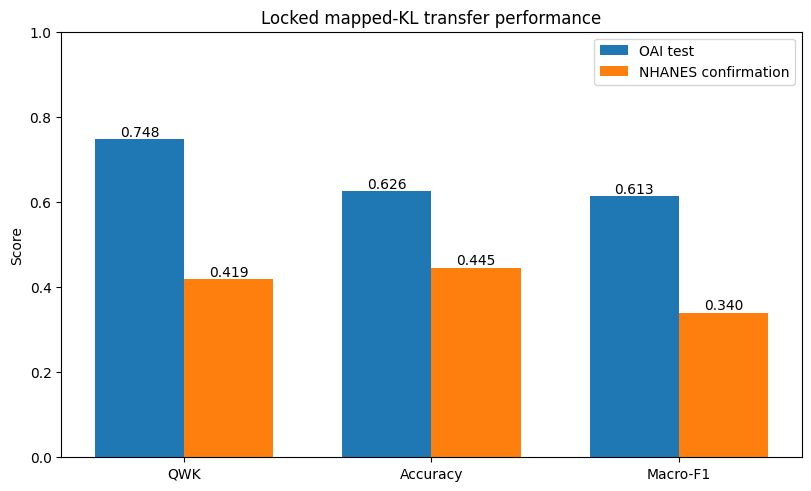

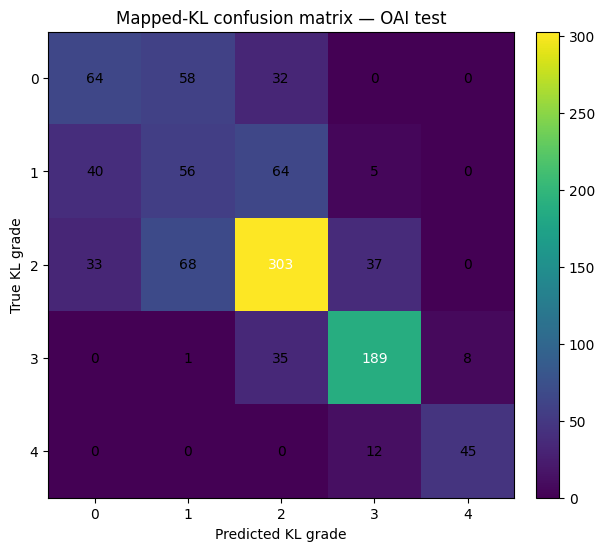

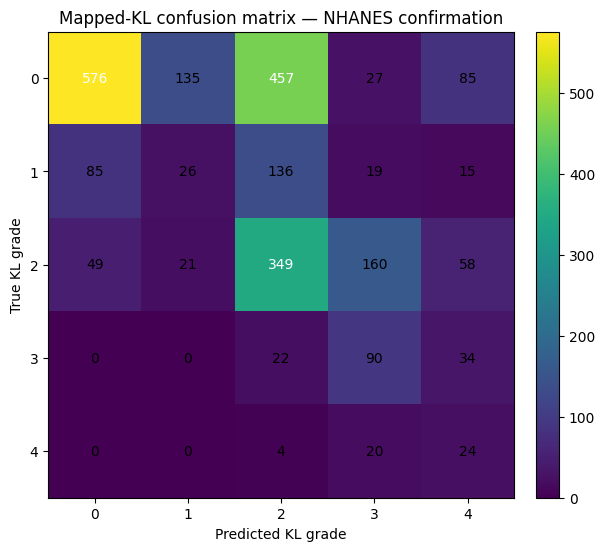

In [ ]:



def save_figure(

    figure,

    name: str,

) -> None:

    figure.savefig(

        FIGURE_DIR

        / f"{name}.png",

        dpi=300,

        bbox_inches="tight",

    )



    figure.savefig(

        FIGURE_DIR

        / f"{name}.pdf",

        bbox_inches="tight",

    )



    plt.show()

    plt.close(figure)





headline = (

    locked_metrics.loc[

        locked_metrics[

            "endpoint"

        ].eq("mapped_kl")

    ]

    .set_index("cohort")

    .loc[

        [

            "OAI",

            "NHANES III",

        ]

    ]

)



metric_names = [

    "qwk",

    "accuracy",

    "macro_f1",

]



x = np.arange(

    len(metric_names)

)



width = 0.36



figure, axis = plt.subplots(

    figsize=(8.0, 4.8),

    constrained_layout=True,

)



oai_values = headline.loc[

    "OAI",

    metric_names,

].to_numpy(dtype=float)



nhanes_values = headline.loc[

    "NHANES III",

    metric_names,

].to_numpy(dtype=float)



oai_bars = axis.bar(

    x - width / 2,

    oai_values,

    width,

    label="OAI test",

)



nhanes_bars = axis.bar(

    x + width / 2,

    nhanes_values,

    width,

    label="NHANES confirmation",

)



axis.set_xticks(

    x,

    [

        "QWK",

        "Accuracy",

        "Macro-F1",

    ],

)



axis.set_ylim(

    0.0,

    1.0,

)



axis.set_ylabel("Score")

axis.set_title(

    "Locked mapped-KL transfer performance"

)

axis.legend()



for bars in (

    oai_bars,

    nhanes_bars,

):

    for bar in bars:

        value = bar.get_height()



        axis.text(

            bar.get_x()

            + bar.get_width() / 2,

            value,

            f"{value:.3f}",

            ha="center",

            va="bottom",

        )



save_figure(

    figure,

    "F01_transfer_metrics",

)





def save_confusion(

    frame: pd.DataFrame,

    title: str,

    name: str,

) -> None:

    matrix = confusion_matrix(

        frame[

            "kl_grade"

        ].to_numpy(dtype=int),

        frame[

            "mapped_kl_prediction"

        ].to_numpy(dtype=int),

        labels=list(range(5)),

    )



    figure, axis = plt.subplots(

        figsize=(6.3, 5.4),

        constrained_layout=True,

    )



    image = axis.imshow(matrix)



    axis.set_xticks(range(5))

    axis.set_yticks(range(5))

    axis.set_xlabel(

        "Predicted KL grade"

    )

    axis.set_ylabel(

        "True KL grade"

    )

    axis.set_title(title)



    threshold = matrix.max() / 2



    for row in range(5):

        for column in range(5):

            axis.text(

                column,

                row,

                str(

                    matrix[

                        row,

                        column,

                    ]

                ),

                ha="center",

                va="center",

                color=(

                    "white"

                    if matrix[

                        row,

                        column,

                    ] > threshold

                    else "black"

                ),

            )



    figure.colorbar(

        image,

        ax=axis,

        fraction=0.046,

        pad=0.04,

    )



    save_figure(

        figure,

        name,

    )





save_confusion(

    OAI_TEST,

    "Mapped-KL confusion matrix — OAI test",

    "F02_confusion_oai",

)



save_confusion(

    NHANES_CONFIRMATION,

    "Mapped-KL confusion matrix — NHANES confirmation",

    "F03_confusion_nhanes",

)


## Final audit and certificate

N02B passes only when all three checkpoints are verified, both evaluation cohorts are nonempty, all required outputs exist, and the bootstrap completes.


In [ ]:



required_files = [

    RESULT_DIR / "image_cache.csv",

    RESULT_DIR / "runtime.json",

    PREDICTION_DIR

    / "oai_predictions.csv",

    PREDICTION_DIR

    / "nhanes_predictions.csv",

    PREDICTION_DIR

    / "nhanes_probabilities.npz",

    TABLE_DIR

    / "T00_probability_audit.csv",

    TABLE_DIR

    / "T01_locked_metrics.csv",

    TABLE_DIR

    / "T02_per_grade_metrics.csv",

    TABLE_DIR

    / "T03_generalization_loss.csv",

    TABLE_DIR

    / "T04_bootstrap_draws.csv",

    TABLE_DIR

    / "T05_bootstrap_intervals.csv",

    FIGURE_DIR

    / "F01_transfer_metrics.png",

    FIGURE_DIR

    / "F01_transfer_metrics.pdf",

    FIGURE_DIR

    / "F02_confusion_oai.png",

    FIGURE_DIR

    / "F02_confusion_oai.pdf",

    FIGURE_DIR

    / "F03_confusion_nhanes.png",

    FIGURE_DIR

    / "F03_confusion_nhanes.pdf",

]



audit_rows = []



for path in required_files:

    exists = path.exists()



    nonempty = (

        exists

        and path.stat().st_size > 0

    )



    fresh = (

        nonempty

        and path.stat().st_mtime

        >= RUN_STARTED_TIMESTAMP - 1.0

    )



    audit_rows.append({

        "file": path.name,

        "path": str(path),

        "exists": exists,

        "nonempty": nonempty,

        "fresh": fresh,

        "size_bytes": (

            int(path.stat().st_size)

            if exists

            else None

        ),

        "sha256": (

            sha256_file(path)

            if nonempty

            else None

        ),

    })



drive_audit = pd.DataFrame(

    audit_rows

)



valid_bootstrap = bool(

    (

        bootstrap_intervals[

            "valid_draws"

        ]

        >= int(

            0.99

            * CONFIG.bootstrap_repetitions

        )

    ).all()

)



criteria = {

    "three frozen checkpoints verified":

        len(SELECTED_MODELS) == 3,



    "checkpoint seeds match N02A":

        sorted(

            item["seed"]

            for item in SELECTED_MODELS

        ) == sorted(expected_seeds),



    "image-model training was not executed":

        EVALUATION_ONLY is True,



    "only NHANES confirmation was evaluated":

        len(NHANES_CONFIRMATION)

        == len(NHANES),



    "OAI test is nonempty":

        len(OAI_TEST) > 0,



    "NHANES confirmation is nonempty":

        len(NHANES_CONFIRMATION) > 0,



    "probability audit passed":

        bool(

            probability_audit[

                [

                    "finite",

                    "nonnegative",

                    "positive_row_mass",

                ]

            ].all().all()

        ),



    "participant bootstrap is valid":

        valid_bootstrap,



    "all required outputs exist":

        bool(

            drive_audit[

                "nonempty"

            ].all()

        ),



    "all outputs are fresh":

        bool(

            drive_audit[

                "fresh"

            ].all()

        ),



    "all output paths use Final Pipeline":

        bool(

            drive_audit[

                "path"

            ].str.startswith(

                str(FINAL_ROOT)

            ).all()

        ),

}



criteria_table = pd.DataFrame([

    {

        "criterion": name,

        "passed": bool(value),

    }

    for name, value in criteria.items()

])



passed = bool(

    criteria_table[

        "passed"

    ].all()

)



atomic_csv(

    drive_audit,

    RESULT_DIR

    / "drive_save_audit.csv",

)



atomic_csv(

    criteria_table,

    RESULT_DIR

    / "acceptance_criteria.csv",

)



status = {

    "stage": "N02B",

    "protocol": PROTOCOL,

    "passed": passed,

    "oai_test_knees": int(

        len(OAI_TEST)

    ),

    "nhanes_confirmation_knees": int(

        len(NHANES_CONFIRMATION)

    ),

    "checkpoint_seeds": [

        int(item["seed"])

        for item in SELECTED_MODELS

    ],

    "image_model_training_executed": False,

    "inference_runtime": INFERENCE_RUNTIME,

    "downstream_inputs": {

        "oai_predictions": str(

            PREDICTION_DIR

            / "oai_predictions.csv"

        ),

        "nhanes_predictions": str(

            PREDICTION_DIR

            / "nhanes_predictions.csv"

        ),

        "nhanes_probabilities": str(

            PREDICTION_DIR

            / "nhanes_probabilities.npz"

        ),

    },

    "created_utc": datetime.now(

        timezone.utc

    ).isoformat(),

}



atomic_json(

    status,

    RESULT_DIR / "status.json",

)



manifest_rows = []



for path in required_files:

    if (

        path.exists()

        and path.stat().st_size > 0

    ):

        manifest_rows.append({

            "path": str(

                path.relative_to(

                    FINAL_ROOT

                )

            ),

            "size_bytes": int(

                path.stat().st_size

            ),

            "sha256": sha256_file(

                path

            ),

            "generator": NOTEBOOK_NAME,

            "protocol": PROTOCOL,

        })



output_manifest = pd.DataFrame(

    manifest_rows

)



atomic_csv(

    output_manifest,

    MANIFEST_DIR

    / "output_manifest.csv",

)



certificate_lines = [

    "=" * 78,

    "N02B LOCKED TRANSFER CERTIFICATE",

    "=" * 78,

]



for row in (

    criteria_table

    .itertuples(index=False)

):

    certificate_lines.append(

        (

            "PASS  "

            if row.passed

            else "FAIL  "

        )

        + str(row.criterion)

    )



certificate_lines.extend([

    "",

    f"Protocol: {PROTOCOL}",

    f"OAI test knees: {len(OAI_TEST)}",

    (

        "NHANES confirmation knees: "

        f"{len(NHANES_CONFIRMATION)}"

    ),

    "NHANES used for training or selection: NO",

    (

        "FINAL STATUS: PASS"

        if passed

        else "FINAL STATUS: FAIL"

    ),

    (

        "READY FOR N03: YES"

        if passed

        else "READY FOR N03: NO"

    ),

    "=" * 78,

])



certificate = "\n".join(

    certificate_lines

)



(

    RESULT_DIR

    / "certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(

    locked_metrics.round(4)

)



display(

    bootstrap_intervals.round(4)

)



display(

    criteria_table

)



print()

print(certificate)



if not passed:

    raise RuntimeError(

        "N02B final audit failed."

    )


,cohort,subset,endpoint,n,accuracy,balanced_accuracy,qwk,macro_f1,weighted_f1,mae,mse,within_one_accuracy,severe_error_rate,nll,brier,ece
0,OAI,test,mapped_kl,1050,0.6257,0.6085,0.7477,0.6133,0.6266,0.4419,0.5771,0.9324,0.0676,0.8993,0.4836,0.0477
1,OAI,test,direct_kl,1050,0.6410,0.6183,0.7393,0.6190,0.6360,0.4438,0.6152,0.9162,0.0838,0.8408,0.4689,0.0421
2,OAI,test,osteophyte_max,1050,0.6000,0.5644,0.7338,0.5607,0.5884,0.4467,0.5419,0.9543,0.0457,0.8819,0.5106,0.0245
3,OAI,test,sclerosis_max,1050,0.7152,0.6348,0.7803,0.6223,0.7150,0.3029,0.3390,0.9819,0.0181,0.6727,0.3852,0.0345
4,NHANES III,confirmation,mapped_kl,2392,0.4452,0.4414,0.4188,0.3395,0.4662,0.9419,1.9645,0.7015,0.2985,1.4841,0.7639,0.1652
5,NHANES III,confirmation,direct_kl,2392,0.4916,0.4395,0.4431,0.3391,0.4937,0.8846,1.8336,0.6944,0.3056,1.2897,0.6775,0.0959
6,NHANES III,confirmation,osteophyte_max,2392,0.4118,0.4450,0.3862,0.2677,0.4900,0.8909,1.5982,0.7483,0.2517,1.4539,0.7438,0.1301
7,NHANES III,confirmation,sclerosis_max,2392,0.6936,0.5295,0.3834,0.3204,0.7175,0.4682,0.8930,0.8888,0.1112,0.7902,0.4091,0.0486


,endpoint,metric,difference_nhanes_minus_oai,ci_lower,ci_upper,valid_draws,requested_draws,bootstrap_unit
0,mapped_kl,qwk,-0.3289,-0.3780,-0.2757,2000,2000,participant within cohort
1,mapped_kl,accuracy,-0.1805,-0.2172,-0.1438,2000,2000,participant within cohort
2,mapped_kl,macro_f1,-0.2738,-0.3138,-0.2337,2000,2000,participant within cohort
3,mapped_kl,mae,0.5000,0.4345,0.5659,2000,2000,participant within cohort
4,mapped_kl,ece,0.1175,0.0730,0.1353,2000,2000,participant within cohort


,criterion,passed
0,three frozen checkpoints verified,True
1,checkpoint seeds match N02A,True
2,image-model training was not executed,True
3,only NHANES confirmation was evaluated,True
4,OAI test is nonempty,True
5,NHANES confirmation is nonempty,True
6,probability audit passed,True
7,participant bootstrap is valid,True
8,all required outputs exist,True
9,all outputs are fresh,True



N02B LOCKED TRANSFER CERTIFICATE
PASS  three frozen checkpoints verified
PASS  checkpoint seeds match N02A
PASS  image-model training was not executed
PASS  only NHANES confirmation was evaluated
PASS  OAI test is nonempty
PASS  NHANES confirmation is nonempty
PASS  probability audit passed
PASS  participant bootstrap is valid
PASS  all required outputs exist
PASS  all outputs are fresh
PASS  all output paths use Final Pipeline

Protocol: N02B_LOCKED_TRANSFER
OAI test knees: 1050
NHANES confirmation knees: 2392
NHANES used for training or selection: NO
FINAL STATUS: PASS
READY FOR N03: YES
